In [ ]:
print('hello')

hello


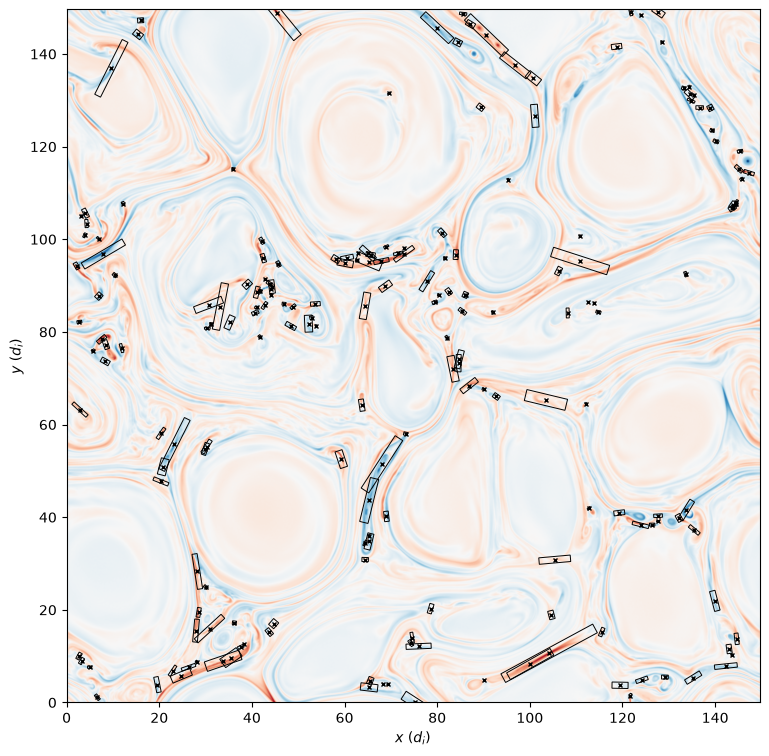

In [20]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

path = "/home/goodwill/149p6_rs/goodwill_149p6.npz"
domain_size = 149.6  # d_i, as used by the existing scripts
base = Path("/home/goodwill/149p6_rs")

with np.load(base / "avg/tbox/f_3.npz") as f:
    jz = f["jz"]

with np.load(path) as data:
    fig, ax = plt.subplots(figsize=(9, 9))

    for i in range(len(data["sno"])):
        center = np.array([
            data["xpts_y"][i],
            data["xpts_x"][i],
        ]) * domain_size / (2 * np.pi)

        # Vectors in plot coordinates: (horizontal, vertical)
        along = data["length"][i] * np.array([
            data["outfl_y"][i], data["outfl_x"][i]
        ])
        across = data["delta"][i] * np.array([
            data["infl_y"][i], data["infl_x"][i]
        ])

        corners = np.array([
            center - along/2 - across/2,
            center + along/2 - across/2,
            center + along/2 + across/2,
            center - along/2 + across/2,
        ])

        ax.add_patch(Polygon(corners, closed=True, fill=False,
                             edgecolor="black", linewidth=0.7))
        ax.plot(*center, marker="x", color="black", markersize=3)
        



    

    i1 = ax.imshow(
        jz, origin="lower",
        extent=(0, domain_size, 0, domain_size),
        cmap="RdBu_r", aspect="equal", vmin=-1.5, vmax=1.5
    )

ax.set(xlim=(0, domain_size), ylim=(0, domain_size),
       xlabel=r"$x\ (d_i)$", ylabel=r"$y\ (d_i)$")
ax.set_aspect("equal")
plt.show()

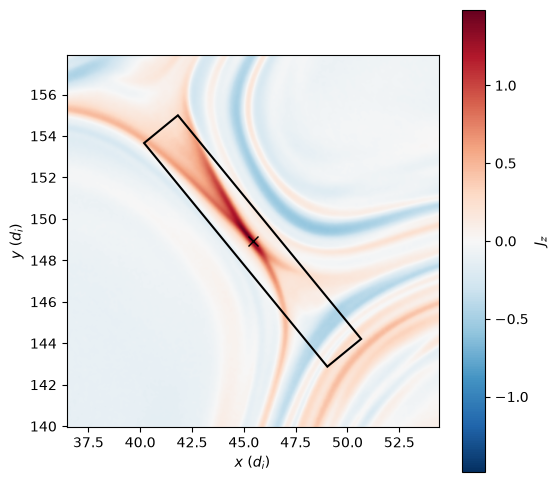

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.ndimage import map_coordinates

data = np.load("/home/goodwill/149p6_rs/goodwill_149p6.npz")
with np.load("/home/goodwill/149p6_rs/avg/tbox/f_3.npz") as fields:
    jz = fields["jz"]
domain_size = 149.6

def zoom_xpoint(i, padding=2):
    center = np.array([data["xpts_y"][i], data["xpts_x"][i]]) \
             * domain_size / (2 * np.pi)

    along = data["length"][i] * np.array(
        [data["outfl_y"][i], data["outfl_x"][i]]
    )
    across = data["delta"][i] * np.array(
        [data["infl_y"][i], data["infl_x"][i]]
    )

    corners = np.array([
        center - along/2 - across/2,
        center + along/2 - across/2,
        center + along/2 + across/2,
        center - along/2 + across/2,
    ])

    radius = max(data["length"][i], data["delta"][i]) / 2 + padding
    xmin, xmax = center[0] - radius, center[0] + radius
    ymin, ymax = center[1] - radius, center[1] + radius

    # Sample Jz on the original (x, y) axes.  grid-wrap makes portions
    # outside [0, domain_size) continue periodically across the boundary.
    ny_full, nx_full = jz.shape
    nx = max(2, int(np.ceil((xmax - xmin) * nx_full / domain_size)))
    ny = max(2, int(np.ceil((ymax - ymin) * ny_full / domain_size)))
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    X, Y = np.meshgrid(x, y)
    jz_zoom = map_coordinates(
        jz,
        [Y * ny_full / domain_size, X * nx_full / domain_size],
        order=1,
        mode="grid-wrap",
    )

    limit = np.nanmax(np.abs(jz_zoom))
    fig, ax = plt.subplots(figsize=(6, 6))
    image = ax.imshow(
        jz_zoom, origin="lower", extent=(xmin, xmax, ymin, ymax),
        cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="equal",
        zorder=0,
    )
    ax.add_patch(Polygon(
        corners, closed=True, fill=False, edgecolor="black",
        linewidth=1.5, zorder=2,
    ))
    ax.plot(*center, marker="x", color="black", markersize=7, zorder=3)
    ax.set(
        xlim=(xmin, xmax), ylim=(ymin, ymax),
        xlabel=r"$x\ (d_i)$", ylabel=r"$y\ (d_i)$",
        # title=f"X-point {int(i)}",
    )
    ax.set_aspect("equal")
    fig.colorbar(image, ax=ax, label=r"$J_z$")
    return fig, ax

fig, ax = zoom_xpoint(67)  # array index; change to inspect another point
plt.show()

In [22]:
base = Path("/home/goodwill/149p6_rs")
domain_size = 149.6  # d_i

f = np.load(base / "avg/tbox/f_3.npz")
de = np.load('/home/goodwill/149p6_rs/avg/tbox/fe_3.npz')
di = np.load('/home/goodwill/149p6_rs/avg/tbox/fi_3.npz')

jeE = de['jex'] * f['ex'] + de['jey'] * f['ey'] + de['jez'] * f['ez']
jiE = di['jix'] * f['ex'] + di['jiy'] * f['ey'] + di['jiz'] * f['ez']

jE = f['jx'] * f['ex'] + f['jy'] * f['ey'] + f['jz'] * f['ez']    
pide = de['pide']
pidi = di['pidi']
pthe = de['pthe']
pthi = di['pthi']

with np.load(base / "goodwill_149p6.npz") as f:
    xpts = {key: f[key].copy() for key in f.files}

with np.load(base / "avg/tbox/f_3.npz") as f:
    jz = f["jz"]
    # jz = f['bz'] - np.mean(f['bz'])

# jz = jE

# jz = -pide - pidi

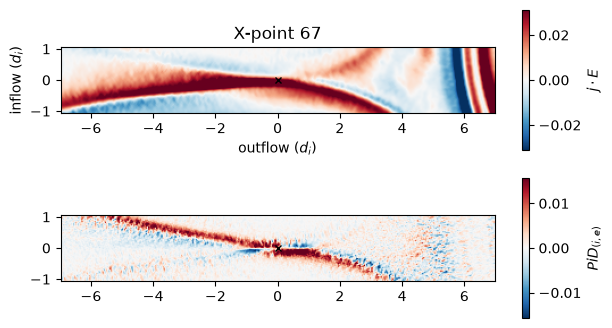

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from pathlib import Path



def plot_jz_region(i):
    ny_full, nx_full = jz.shape
    length = float(xpts["length"][i])
    width = float(xpts["delta"][i])

    # About one output pixel per simulation pixel.
    nx = max(2, int(np.ceil(length * nx_full / domain_size)))
    ny = max(2, int(np.ceil(width * ny_full / domain_size)))

    along = (np.arange(nx) + 0.5) * length / nx - length / 2
    across = (np.arange(ny) + 0.5) * width / ny - width / 2
    A, B = np.meshgrid(along, across)

    # Center and directions in the plotting convention used by your scripts.
    cx = xpts["xpts_y"][i] * domain_size / (2 * np.pi)
    cy = xpts["xpts_x"][i] * domain_size / (2 * np.pi)
    X = cx + A*xpts["outfl_y"][i] + B*xpts["infl_y"][i]
    Y = cy + A*xpts["outfl_x"][i] + B*xpts["infl_x"][i]

    # jz[row, column] = jz[vertical, horizontal].
    r1= map_coordinates(
        jE,
        [Y * ny_full / domain_size,
         X * nx_full / domain_size],
        order=1,
        mode="grid-wrap",  # periodic simulation domain
    )

    r2= map_coordinates(
        -(pide),
        [Y * ny_full / domain_size,
         X * nx_full / domain_size],
        order=1,
        mode="grid-wrap",  # periodic simulation domain
    )

    l1 = np.nanmax(np.abs(r1))
    l2 = np.nanmax(np.abs(r2))  

    fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(7, 4))
    i1 = ax1.imshow(
        r1, origin="lower",
        extent=(-length/2, length/2, -width/2, width/2),
        cmap="RdBu_r", aspect="equal", vmin=-l1/2, vmax=l1/2
    )
    i2 = ax2.imshow(
        r2, origin="lower",
        extent=(-length/2, length/2, -width/2, width/2),
        cmap="RdBu_r", aspect="equal", vmin=-l2/2, vmax=l2/2
    )

    ax1.plot(0, 0, "kx", markersize=5)
    ax2.plot(0, 0, "kx", markersize=5)
    ax1.set_xlabel("outflow ($d_i$)")
    ax1.set_ylabel("inflow ($d_i$)")
    ax1.set_title(f"X-point {int(i)}")
    fig.colorbar(i1, ax=ax1, label=r"$j \cdot E$")
    fig.colorbar(i2, ax=ax2, label=r"$PiD_{(i,e)}$")
    return fig

fig = plot_jz_region(67)
plt.show()

0
X-point 142:,X = 104.16,Y = 10.63, width=2.12, 
X-point  67:,X = 45.42,Y = 148.93, width=2.11, 
X-point  95:,X = 68.07,Y = 51.42, width=1.95, 
X-point  18:,X = 9.66,Y = 136.90, width=1.40, 
X-point 148:,X = 110.85,Y = 95.31, width=2.12, 
X-point  29:,X = 23.28,Y = 55.70, width=1.39, 
X-point 133:,X = 90.64,Y = 144.08, width=1.94, 
X-point 138:,X = 100.07,Y = 8.31, width=1.66, 
X-point  15:,X = 7.93,Y = 96.82, width=1.52, 
X-point  43:,X = 33.20,Y = 85.48, width=1.60, 


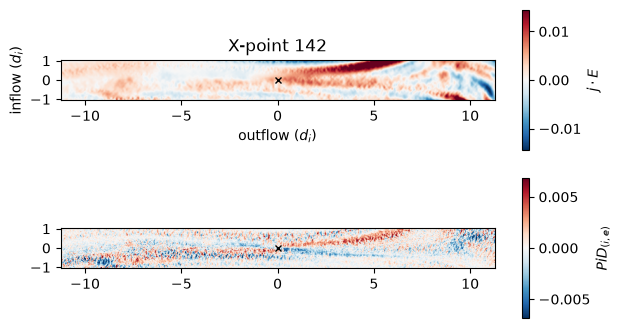

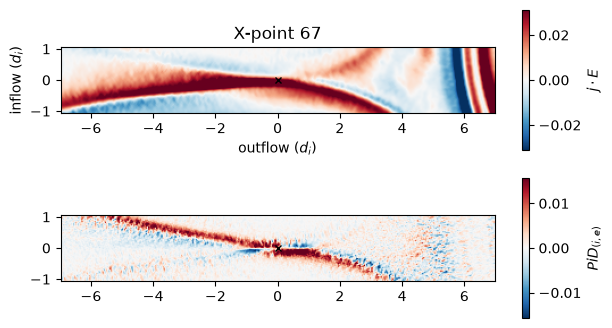

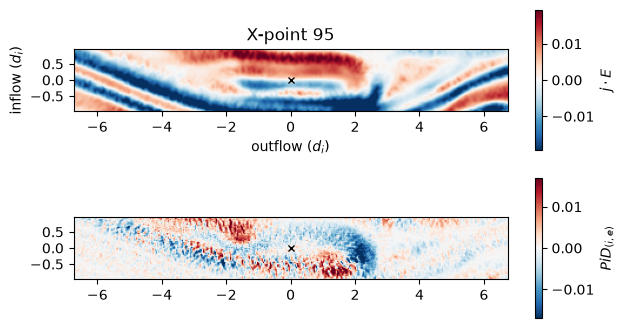

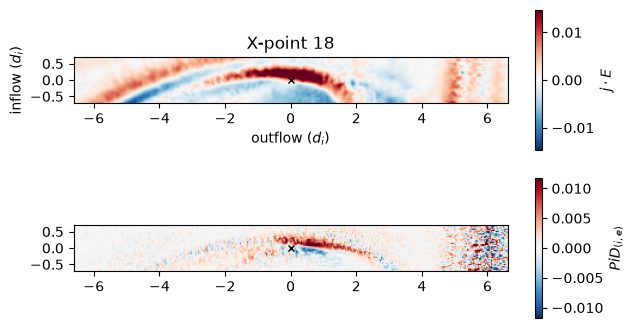

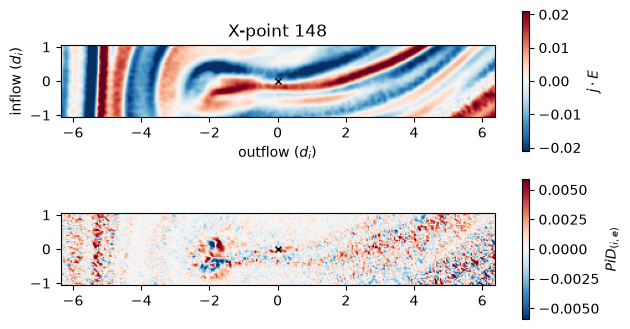

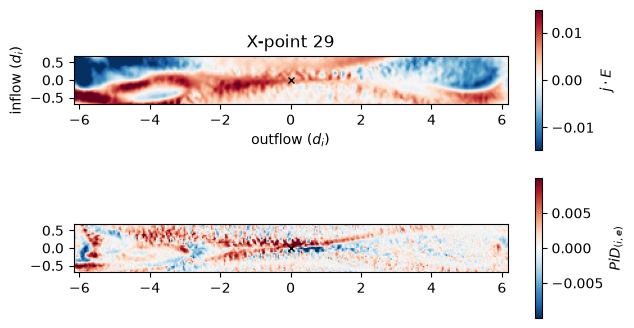

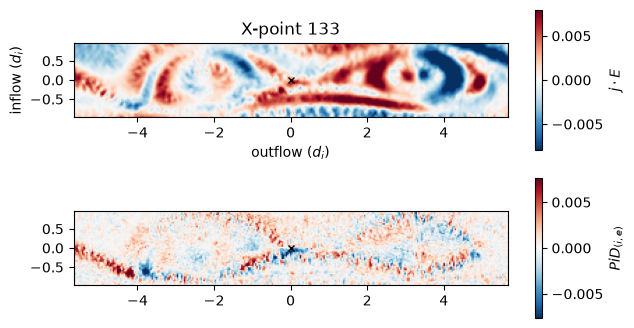

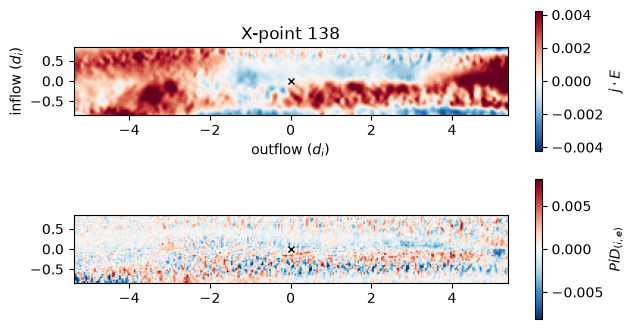

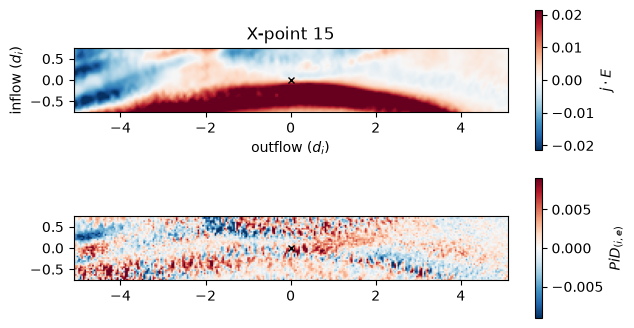

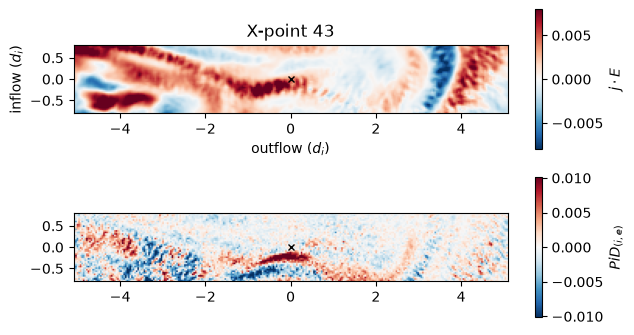

In [24]:
sorted_indices = np.argsort(xpts["length"])[::-1]  # largest first


# rng = int(len(sorted_indices)) - 181
rng = 0
print(rng)

for i in sorted_indices[rng:rng+10]:
    print(f"X-point {int(i):3d}:,"
          f"X = {xpts['xpts_y'][i] * domain_size / (2 * np.pi):.2f},"
          f"Y = {xpts['xpts_x'][i] * domain_size / (2 * np.pi):.2f}, "
          f"width={xpts['delta'][i]:.2f}, ")
        #   f"area={area[i]:.2f}")

for i in sorted_indices[rng:rng+10]:
    fig = plot_jz_region(i)
    plt.show()
    plt.close(fig)
